# 1 引言

### 研究目的
本文借鉴方正证券《方正：“市场行为的宝藏”系列研究（一）：行业轮动的黄金律，日内动量与隔夜反转》中的研究成果，对相关结论展开分析，并对比传统动量因子策略，以及将传统动量因子拆分为日内涨跌幅因子与隔夜涨跌幅因子后的应用效果。

### 研究内容
不同类型的交易者群体具备差异化的行为模式。在交易日的不同时间段，交易者结构往往存在系统性区别，进而表现出不同的市场行为特征，最终形成各类日内模式（intraday patterns）。基于这一逻辑，为探究动量效应在日内层面的精细化规律，本文将行业指数的日收益率拆分为日内收益率（今收/今开-1）与隔夜收益率（今开/昨收-1）两部分。
1）对过去15个交易日的日内收益率进行加总，构建日内涨跌幅因子M0；对过去15个交易日的隔夜收益率进行加总，构建隔夜涨跌幅因子M1。
2）将上述两类效应进行融合，搭建全新的行业轮动模型。具体操作方式为：对N个行业指数依据M0因子值由低至高依次赋予1至N分，依据M1因子值由高至低依次赋予1至N分，将两项得分加总得到各行业的综合得分，该综合指标命名为黄金律因子M_gold。
3）行业轮动回测框架设定如下：
测试区间：2006年1月-2017年11月；
研究样本：申万一级行业指数（合计28个）；
调仓规则：每月月初依据行业指数总得分排序并分为五组，持仓持有至月末；总得分最高的组合为多头组合，总得分最低的组合为空头组合。

### 本文所用因子构建细节
结合研究设计，本文所使用的四项因子具体构建方式如下：
1）传统动量因子：过去15个交易日涨跌幅。
2）日内涨跌幅因子M0：过去15个交易日日内收益率加总，其中日内收益率计算公式为今收/今开-1。
3）隔夜涨跌幅因子M1：过去15个交易日隔夜收益率加总，其中隔夜收益率计算公式为今开/昨收-1。
4）黄金律因子M_gold：采用打分法对日内涨跌幅因子与隔夜涨跌幅因子进行等权加权，构建黄金律因子；其中日内涨跌幅因子遵循动量效应，按因子值由低至高赋予1至N分，隔夜涨跌幅因子遵循反转效应，按因子值由高至低赋予1至N分。

### 研究结论
1）本文将传统动量因子（即过去15个交易日涨跌幅）进行拆分，进一步刻画交易者的行为模式，验证了交易者存在差异化的日内交易特征，为新型因子的开发提供了研究思路。
2）行业指数存在“日内动量、隔夜反转”的规律特征：日内涨跌幅因子M0（过去15个交易日日内收益率加总）表现出显著的动量效应，因子值越高的组合收益表现越优；隔夜涨跌幅因子M1（过去15个交易日隔夜收益率加总）表现出反转效应，因子值越低的组合超额收益越突出。
3）基于打分法等权融合两类因子构建的黄金律因子，应用于行业轮动组合时，头部组合年化收益提升幅度约7%，同时最大回撤得到显著优化。与传统动量因子0.68的夏普比率相比，黄金律因子夏普比率可达到0.87。

### 数据准备部分
下述内容均基于聚源数据库调取数据开展相关操作，具体数据源可参考对应链接。

In [ ]:
# 基础库导入与绘图环境初始化
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 绘图风格与全局参数配置
sns.set_style("whitegrid", {"axes.facecolor": "0.99"})
sns.set_context(
    "notebook",
    font_scale=1.2,
    rc={"lines.linewidth": 1.5}
)

# 解决负号显示异常问题
plt.rcParams['axes.unicode_minus'] = False
# 设置全局默认字体
plt.rcParams['font.family'] = 'sans-serif'

# 2. 导入数据
下述内容均基于聚源数据库开展数据调取操作，通过`get_SW_index`函数提取各申万二级行业指数的相关数据，借助`index_list`明确待提取的指标类型（如收盘价`ClosePrice`等），其中`codelist`为申万二级行业指数的代码集合，可通过`get_SW_index`函数完成交易数据的提取。

设定回测的起始时间与终止时间，将`index_list`设定为收盘价与开盘价，通过`get_SW_index`函数分别提取全部申万二级行业指数的收盘价与开盘价数据。

In [2]:
# 申万行业指数行情数据批量获取接口
def fetch_sw_index_data(sw_code, start_dt, end_dt, target_cols=['ClosePrice']):
    """
    从聚源数据库提取单条申万行业指数的行情数据
    """
    # 查询指数基础信息获取内部编码
    stock_info = jy.run_query(
        query(jy.SecuMain).filter(
            jy.SecuMain.SecuCode == str(sw_code)
        )
    )
    
    target_info = stock_info[stock_info.SecuCode == str(sw_code)]
    index_pos = stock_info[stock_info.SecuCode == str(sw_code)].index.tolist()
    inner_code = target_info['InnerCode'][index_pos]
    
    # 按时间区间提取指数行情
    index_quote = jy.run_query(
        query(jy.QT_SYWGIndexQuote).filter(
            jy.QT_SYWGIndexQuote.InnerCode == str(inner_code.values[0]),
            jy.QT_SYWGIndexQuote.TradingDay >= start_dt,
            jy.QT_SYWGIndexQuote.TradingDay <= end_dt
        )
    )
    
    index_quote.index = index_quote['TradingDay']
    index_quote = index_quote[target_cols]
    index_quote.columns = [sw_code]
    
    return index_quote

# 申万一级行业指数代码列表
sw_index_codes = [
    801010, 801020, 801030, 801040, 801050, 801080,
    801110, 801120, 801130, 801140, 801150, 801160,
    801170, 801180, 801200, 801210, 801230, 801710,
    801720, 801730, 801740, 801750, 801760, 801770,
    801780, 801790, 801880, 801890
]

# 数据提取时间区间
start_dt = datetime(2012, 1, 1)
end_dt = datetime(2024, 12, 31)

# 批量获取收盘价数据
close_price_df = pd.DataFrame()
for idx in range(len(sw_index_codes)):
    index_data = fetch_sw_index_data(
        sw_code=sw_index_codes[idx],
        start_dt=start_dt,
        end_dt=end_dt,
        target_cols=['ClosePrice']
    )
    close_price_df = pd.concat([close_price_df, index_data], axis=1)

# 批量获取开盘价数据
open_price_df = pd.DataFrame()
for idx in range(len(sw_index_codes)):
    index_data = fetch_sw_index_data(
        sw_code=sw_index_codes[idx],
        start_dt=start_dt,
        end_dt=end_dt,
        target_cols=['OpenPrice']
    )
    open_price_df = pd.concat([open_price_df, index_data], axis=1)

In [3]:
print(close_price_df)

              801010    801020    801030    ...       801790    801880    801890
TradingDay                                  ...                                 
2012-01-04  1659.451  4365.053  1655.204    ...      862.480  2350.720   878.500
2012-01-05  1569.127  4288.620  1599.421    ...      851.920  2317.100   848.520
2012-01-06  1543.904  4338.680  1613.570    ...      862.690  2317.520   850.580
2012-01-09  1599.414  4633.904  1688.509    ...      892.880  2408.710   888.340
2012-01-10  1684.107  4850.141  1755.611    ...      927.130  2501.560   931.250
2012-01-11  1691.852  4839.950  1756.805    ...      920.910  2499.630   929.580
2012-01-12  1676.900  4810.077  1760.384    ...      920.530  2495.990   926.700
2012-01-13  1617.076  4750.375  1705.601    ...      904.640  2409.570   892.310
2012-01-16  1561.900  4648.061  1651.754    ...      895.850  2372.840   873.750
2012-01-17  1642.199  4964.823  1749.062    ...      950.910  2504.500   926.130
2012-01-18  1597.166  4863.4

In [4]:
print(open_price_df)

              801010    801020    801030    ...       801790    801880    801890
TradingDay                                  ...                                 
2012-01-04  1711.962  4529.341  1706.521    ...      887.450  2420.110   912.290
2012-01-05  1646.097  4337.532  1644.868    ...      857.340  2339.720   871.100
2012-01-06  1558.593  4286.423  1596.330    ...      849.780  2305.940   844.200
2012-01-09  1543.321  4338.833  1612.970    ...      861.870  2323.350   850.260
2012-01-10  1604.249  4654.805  1685.328    ...      891.000  2409.970   885.840
2012-01-11  1682.761  4853.983  1753.441    ...      925.580  2498.680   928.640
2012-01-12  1680.454  4801.540  1749.546    ...      917.450  2488.180   924.330
2012-01-13  1677.274  4820.291  1757.927    ...      921.570  2497.540   925.930
2012-01-16  1600.439  4706.969  1684.231    ...      901.550  2392.570   883.080
2012-01-17  1561.450  4656.408  1653.260    ...      897.280  2372.860   874.150
2012-01-18  1644.328  4961.4

# 3. 黄金律：日内动量+隔夜反转

不同交易者群体具有差异化的行为模式。在交易日的不同时段，交易者结构可能存在系统性差异，进而导致不同的市场行为特征，最终形成多样的日内模式（intraday patterns）。基于这一思路，为探究动量效应的日内精细化规律，本报告将行业指数的日收益率拆解为日内收益率（今收/今开-1）与隔夜收益率（今开/昨收-1）两部分。

在本报告中，我们对过去15个交易日的日内收益率进行加总处理，将其命名为日内涨跌幅因子M0；同时，对过去15个交易日的隔夜收益率进行加总处理，将其称为隔夜涨跌幅因子M1。

In [3]:
# 初始化回测基础配置参数
# 定义回测时间范围与核心参数
backtest_start_year = '2012'
backtest_end_year = '2021'

# 自定义参数序列1
param_group1 = [23, 17, 11, 5, 0]

# 自定义参数序列2
param_group2 = [27, 22, 16, 10, 4]


def_alpha函数依据前文所述的因子计算逻辑，实现四类因子的测算工作，分别为：传统动量因子M、日内涨跌幅因子M0、隔夜涨跌幅因子M1，以及由M1与M2合成的复合因子M_gold。

后续通过report函数对上述四类因子的选股效果开展对比分析，该函数可完成年化收益率、最大回撤等核心指标的计算，实现对策略收益的量化评估。本文同时列示传统动量因子的计算结果，具体如下：

In [4]:
# 计算因子信号与收益指标
def calculate_alpha_signal(open_prices, close_prices, start_dt, end_dt):
    # 日内收益率：收盘/开盘 - 1
    intraday_return = (close_prices / open_prices) - 1
    # 隔夜收益率：次日开盘/前日收盘 - 1
    overnight_return = pd.DataFrame(
        (np.array(open_prices.iloc[1:]) / np.array(close_prices.iloc[:-1])) - 1,
        columns=intraday_return.columns,
        index=intraday_return.index[1:]
    )
    
    # 15日趋势指标
    trend_15d = close_prices.pct_change(15).dropna()
    # 日内收益15日滚动求和
    sum_intraday_15d = intraday_return.rolling(15).sum().dropna()
    # 隔夜收益15日滚动求和
    sum_overnight_15d = overnight_return.rolling(15).sum().dropna()
    
    # 统一时间索引格式
    sum_intraday_15d.index = pd.to_datetime(sum_intraday_15d.index.astype(str))
    sum_overnight_15d.index = pd.to_datetime(sum_overnight_15d.index.astype(str))
    
    # 截面排名
    rank_intraday = sum_intraday_15d.rank(axis=1)
    rank_overnight = sum_overnight_15d.rank(axis=1, ascending=False)
    
    # 合成综合信号
    combined_signal = rank_intraday + rank_overnight
    
    return trend_15d, sum_intraday_15d, sum_overnight_15d, combined_signal

# 执行信号计算
trend_15d, sum_intraday_15d, sum_overnight_15d, combined_signal = calculate_alpha_signal(
    price_open, price_close, start_date, end_date
)

# 策略绩效评价报告
def generate_performance_report(return_series, freq=1):
    # 缺失值填充
    return_series = return_series.fillna(0)
    # 累计净值
    cumulative_net = (1 + return_series).cumprod()
    
    # 核心指标计算
    annual_return = (cumulative_net.iloc[-1] / cumulative_net.iloc[0]) ** (242 / freq / len(cumulative_net)) - 1
    annual_vol = np.std(return_series) * np.sqrt(242 / freq)
    sharpe_ratio = annual_return / annual_vol
    
    # 最大回撤
    drawdown_series = cumulative_net / cumulative_net.cummax() - 1
    max_drawdown = -drawdown_series.min()
    
    # 构建结果表
    performance_df = pd.DataFrame(index=[0])
    performance_df["年化收益率"] = f"{round(annual_return.iloc[0] * 100, 2)}%"
    performance_df["年化波动率"] = f"{round(annual_vol.iloc[0] * 100, 2)}%"
    performance_df["收益波动比"] = f"{round(sharpe_ratio.iloc[0], 2)}"
    performance_df["最大回撤"] = f"{round(max_drawdown.iloc[0] * 100, 2)}%"
    
    return performance_df

# 查看趋势指标前5行
trend_15d.head()

,801010,801020,801030,801040,801050,801080,801110,801120,801130,801140,801150,801160,801170,801180,801200,801210,801230,801710,801720,801730,801740,801750,801760,801770,801780,801790,801880,801890
TradingDay,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-12-24,0.159446,0.161686,0.134648,0.083637,0.146519,0.142301,0.102923,0.077406,0.141659,0.128187,0.085816,0.089618,0.088571,0.100149,0.121880,0.089193,0.113375,0.175912,0.122919,0.136241,0.134617,0.133066,0.106994,0.107305,0.166654,0.192658,0.156717,0.143355
2012-12-25,0.182066,0.180449,0.144581,0.094346,0.152440,0.143987,0.116783,0.086523,0.155940,0.141395,0.102950,0.095149,0.109665,0.135960,0.138567,0.094513,0.128925,0.188117,0.135513,0.149444,0.137321,0.137158,0.122406,0.117535,0.204042,0.196939,0.165309,0.157727
2012-12-26,0.158294,0.141499,0.121007,0.071862,0.117212,0.120399,0.087435,0.085439,0.133741,0.131333,0.076377,0.072729,0.087983,0.119575,0.117176,0.085685,0.103832,0.127053,0.106572,0.128571,0.118202,0.115095,0.112774,0.099288,0.153986,0.140119,0.127609,0.119013
2012-12-27,0.142171,0.143681,0.116088,0.081181,0.124332,0.110594,0.075863,0.106250,0.115531,0.129317,0.073395,0.075684,0.086317,0.102315,0.105622,0.099719,0.099792,0.102729,0.100888,0.116469,0.121757,0.098027,0.103919,0.090709,0.133376,0.136530,0.126030,0.108289
2012-12-28,0.096246,0.120024,0.092661,0.061848,0.111005,0.095488,0.091390,0.098448,0.102694,0.112117,0.064798,0.068351,0.079871,0.119251,0.096375,0.089451,0.097094,0.082343,0.095726,0.102323,0.124994,0.095443,0.093961,0.083344,0.119843,0.149708,0.116692,0.092684


本节借助 resample 函数构建 get_month 函数，实现基于因子索引提取月初时间点与月末时间点的功能，其中月末时间点输出结果如下所示。
此外，本文采用打分法开展选股操作，get_alpharank 函数用于实现因子排序功能，传入因子数据与对应日期参数后，即可输出当日因子的排序数值。

In [7]:
# 提取月度首尾交易日
def fetch_monthly_trading_dates(alpha_data):
    """
    从时间序列索引中提取每个月的第一个与最后一个交易日
    通过按月重采样实现日期聚合
    """
    # 提取每月首个交易日
    monthly_start = pd.Series(alpha_data.index, index=alpha_data.index).resample('M').first().dropna()
    # 提取每月最后交易日
    monthly_end = pd.Series(M0.index, index=M0.index).resample('M').last().dropna()
    
    return monthly_start, monthly_end

# 执行月度交易日提取
monthly_start_dates, monthly_end_dates = fetch_monthly_trading_dates(M)

# 查看月末交易日序列
monthly_end_dates.head()

# 计算因子排名
def calculate_alpha_rank(alpha_data, target_date):
    """
    根据指定日期提取因子截面数据，并计算行业排名
    返回按因子值升序排列的排名结果
    """
    # 提取指定日期的因子截面
    alpha_slice = alpha_data.loc[target_date]
    # 计算行业排名矩阵
    rank_matrix = pd.DataFrame(np.argsort(np.array(alpha_slice), axis=1), index=alpha_slice.index)
    
    return rank_matrix

本节可对调仓节点对应的净值进行核算，例如 group1 与 a1 分别代表传统动量因子第一分组的测算结果。下图展示了以 15 日涨跌幅作为代理变量的传统动量因子，在申万二级行业指数行业轮动中的应用效果。从结果可以看出，五组分组对应的净值曲线区分度相对较弱。

            0   1   2   3   4   5   6   7  ...  20  21  22  23  24  25  26  27
TradingDay                                 ...                                
2012-12-31   3  10   0  11   5  27  12  17 ...   9   4   1  26  13  24  20  25
2013-01-31   7   3   8  18  14  13  19  23 ...  16   2  26   6  10  25  20  24
2013-02-28   1   4  24   3  12  13  15  17 ...  11  19  16  21  20  10   5  22
2013-03-29  25   0   4   7  24   1  20  19 ...  23  13   5  11  21  15   6  10
2013-04-26  20   1   4   3  11   0  15   2 ...  21  18   6  19  23   5  26  22
2013-05-31   6   3   1   4   7  24  25  26 ...  13  27   0  19  22  20   5  21
2013-06-28   4   1  17   8  25  16   3  20 ...  19   6  10   5   7  23  21  22
2013-07-31  24   7  26  20  18   1  13   4 ...   6  10  27   5  15  23  21  22
2013-08-30  10   5  11   6   7   2   0  27 ...   9  21   8  16  24  15  14  12
2013-09-30  17  18   3   4  13   5   2   1 ...  19  25   6  21  10  15  14  22
2013-10-31  22  21  14  23   5  15   4  16 ...   8  

<Figure size 432x288 with 0 Axes>

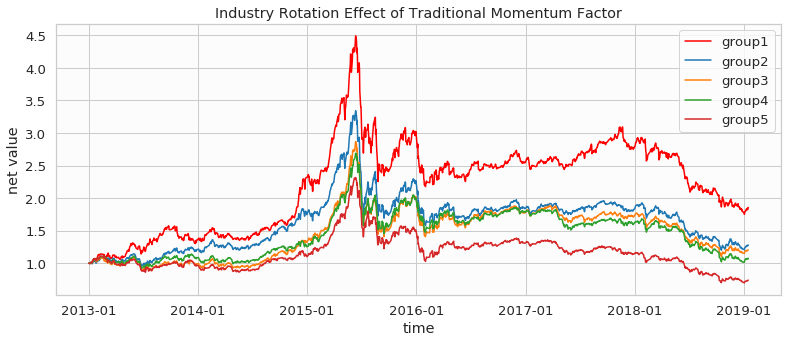

In [9]:
# 基于因子分层的行业轮动回测函数
def run_group_backtest(group_id, total_groups, param_set1, param_set2, price_data, rank_matrix, rebalance_dates):   
    # 初始化分组收益与净值存储容器
    group_holding = pd.DataFrame(np.zeros((len(price_data.loc[rebalance_dates[0]:]), total_groups)), 
                                 index=price_data.loc[rebalance_dates[0]:].index)
    portfolio_nav = pd.DataFrame(np.zeros((len(price_data.loc[rebalance_dates[0]:]), 1)), 
                                 index=price_data.loc[rebalance_dates[0]:].index)
    
    # 循环迭代与仓位初始化
    current_idx = 0
    current_capital = 1
    
    # 按月度调仓周期执行回测
    while current_idx < len(rebalance_dates) - 1:
        current_date = rebalance_dates[current_idx]
        next_date = rebalance_dates[current_idx + 1]
        
        # 选取当期排名对应的行业组合
        selected_cols = rank_matrix.loc[current_date, param_set1[group_id-1] : param_set2[group_id-1]]
        selected_df = price_data.iloc[:, selected_cols]
        
        # 截取当期持仓周期数据
        holding_df = selected_df.loc[current_date : next_date]
        holding_df = pd.DataFrame(holding_df.values, index=price_data.loc[current_date : next_date].index)
        
        # 计算等权组合收益
        position_weight = (current_capital / total_groups) / holding_df.iloc[0, :]
        period_return = (position_weight * holding_df).sum(axis=1)
        
        # 更新资金与持仓记录
        current_capital = period_return.iloc[-1]
        group_holding.loc[current_date : next_date - timedelta(1)] = holding_df
        portfolio_nav.loc[current_date : next_date - timedelta(1)] = pd.DataFrame(period_return)
        
        current_idx += 1
    
    # 剔除尾部无效数据
    group_holding = group_holding.iloc[:-10]
    portfolio_nav = portfolio_nav.iloc[:-10]
    
    return group_holding, portfolio_nav

# 执行五组分层回测
group1, nav1 = run_group_backtest(1, 5, u1, u2, price_close, t, ym_end)
group2, nav2 = run_group_backtest(2, 6, u1, u2, price_close, t, ym_end)
group3, nav3 = run_group_backtest(3, 6, u1, u2, price_close, t, ym_end)
group4, nav4 = run_group_backtest(4, 6, u1, u2, price_close, t, ym_end)
group5, nav5 = run_group_backtest(5, 5, u1, u2, price_close, t, ym_end)

# 分组净值曲线可视化
plt.figure()
performance_fig = plt.figure(figsize=(13, 5))
axis = performance_fig.add_subplot(1, 1, 1)

axis.plot(nav1, 'r', label='组合 1')
axis.plot(nav2, label='组合 2')
axis.plot(nav3, label='组合 3')
axis.plot(nav4, label='组合 4')
axis.plot(nav5, label='组合 5')

axis.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
plt.legend(loc='best')
plt.xlabel('时间')
plt.ylabel('净值')
plt.title('Industry Rotation Effect of Traditional Momentum Factor')
plt.show()

我们同时展示了多空组合净值（第 1 组减去第 5 组）的运行走势，结果显示其上升趋势稳定性不足，且回撤幅度偏高。这表明，直接依托指数前期涨跌幅构建的动量轮动策略，整体应用效果未达预期。

No handles with labels found to put in legend.


<Figure size 432x288 with 0 Axes>

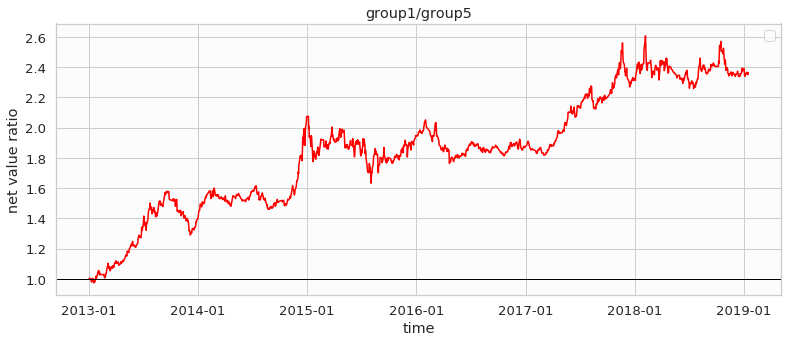

In [10]:
# 计算多空对冲收益（组1 - 组5）
hedge_returns = nav1.pct_change() - nav5.pct_change()

# 计算对冲组合累计净值
cumulative_hedge = (hedge_returns.fillna(0) + 1).cumprod()

# 可视化多空对冲净值曲线
plt.figure()
performance_fig = plt.figure(figsize=(13, 5))
axis = performance_fig.add_subplot(1, 1, 1)

axis.plot(cumulative_hedge, 'r', label='多空对冲净值')
axis.axhline(1.0, linestyle='-', color='black', linewidth=1)
axis.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))

plt.legend(loc='best')
plt.xlabel('time')
plt.ylabel('net value ratio')
plt.title('group1/group5')
plt.show()

In [11]:
# 生成各分组策略绩效评价表格
performance_table_1 = pd.DataFrame(generate_performance_report(nav1.pct_change(), freq=1))
performance_table_1.index = ['组合一']

performance_table_2 = pd.DataFrame(generate_performance_report(nav2.pct_change(), freq=1))
performance_table_2.index = ['组合二']

performance_table_3 = pd.DataFrame(generate_performance_report(nav3.pct_change(), freq=1))
performance_table_3.index = ['组合三']

performance_table_4 = pd.DataFrame(generate_performance_report(nav4.pct_change(), freq=1))
performance_table_4.index = ['组合四']

performance_table_5 = pd.DataFrame(generate_performance_report(nav5.pct_change(), freq=1))
performance_table_5.index = ['组合五']

# 合并所有组合绩效结果并输出总表
pd.concat([performance_table_1, performance_table_2, performance_table_3,
           performance_table_4, performance_table_5], axis=0)

,年化收益率,年化波动率,收益波动比,最大回撤
组合一,10.69%,26.74%,0.4,61.01%
组合二,4.14%,25.58%,0.16,64.08%
组合三,3.11%,25.07%,0.12,61.56%
组合四,1.12%,24.72%,0.05,62.29%
组合五,-4.81%,25.15%,-0.19,69.87%


为检验各因子对行业指数未来收益的预测效果，我们分别依据 M0、M1 因子值从高到低对行业指数进行排序并划分为 5 组，于每个自然月月末执行调仓操作。下图展示了两种因子分组下各投资组合的年化收益率水平。研究结论表明：日内涨跌幅因子 M0 表现出显著的动量效应，而隔夜涨跌幅因子 M1 则呈现出明显的反转效应。

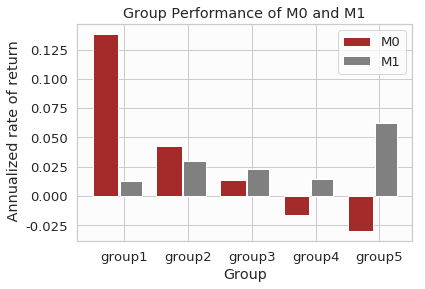

In [12]:
# 计算 M0 因子排名并执行分组回测
rank_m0 = calculate_alpha_rank(M0, ym_end)

portfolio_01, nav_01 = get_group(1, 5, u1, u2, price_close, rank_m0, ym_end)
portfolio_02, nav_02 = get_group(2, 6, u1, u2, price_close, rank_m0, ym_end)
portfolio_03, nav_03 = get_group(3, 6, u1, u2, price_close, rank_m0, ym_end)
portfolio_04, nav_04 = get_group(4, 6, u1, u2, price_close, rank_m0, ym_end)
portfolio_05, nav_05 = get_group(5, 5, u1, u2, price_close, rank_m0, ym_end)

# 计算 M0 各组年化收益率
annual_m0 = pd.DataFrame(np.zeros((5, 1)), index=['分组一', '分组二', '分组三', '分组四', '分组五'])
annual_m0.iloc[0] = (nav_01.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m0.iloc[1] = (nav_02.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m0.iloc[2] = (nav_03.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m0.iloc[3] = (nav_04.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m0.iloc[4] = (nav_05.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1

# 计算 M1 因子排名并执行分组回测
rank_m1 = calculate_alpha_rank(M1, ym_end)

portfolio_11, nav_11 = get_group(1, 5, u1, u2, price_close, rank_m1, ym_end)
portfolio_12, nav_12 = get_group(2, 6, u1, u2, price_close, rank_m1, ym_end)
portfolio_13, nav_13 = get_group(3, 6, u1, u2, price_close, rank_m1, ym_end)
portfolio_14, nav_14 = get_group(4, 6, u1, u2, price_close, rank_m1, ym_end)
portfolio_15, nav_15 = get_group(5, 5, u1, u2, price_close, rank_m1, ym_end)

# 计算 M1 各组年化收益率
annual_m1 = pd.DataFrame(np.zeros((5, 1)), index=['分组一', '分组二', '分组三', '分组四', '分组五'])
annual_m1.iloc[0] = (nav_11.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m1.iloc[1] = (nav_12.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m1.iloc[2] = (nav_13.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m1.iloc[3] = (nav_14.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1
annual_m1.iloc[4] = (nav_15.iloc[-1]) ** (1 / (len(portfolio_01) / 240)) - 1

# 分组年化收益率对比可视化
plt.bar(np.arange(5), np.array(annual_m0[0]), 0.4, color='brown', label='M0')
plt.bar(np.arange(5) + 0.4, np.array(annual_m1[0]), 0.35, color='gray', label='M1')
plt.xlabel('Group')
plt.ylabel('Annualized rate of return')
plt.title('Group Performance of M0 and M1')
plt.xticks(np.arange(5) + 0.3, ('group1', 'group2', 'group3', 'group4', 'group5'))
plt.legend()
plt.show()

# 4. 基于黄金律的行业轮动模型
根据前文研究结论，行业指数存在“日内动量”与“隔夜反转”的黄金律特征，据此，本文尝试将这两种效应进行融合，构建全新的行业轮动模型。具体操作流程为：针对N个行业指数，依据M0因子值由低至高依次赋予1至N分，依据M1因子值由高至低依次赋予1至N分，再将两项得分进行加总，得到各行业的综合得分。

行业轮动回测框架设定如下：
1)  测试时段：2006年1月-2017年11月；
2)  样本空间：申万一级行业指数（共28个）；
3)  调仓方式：每月月初，按照综合得分对行业指数进行排序并划分为五组，各组持仓均持有至当月月末；
4)  综合得分最高的组合作为多头组合，综合得分最低的组合作为空头组合。

下图为各分组的净值走势曲线。

<Figure size 432x288 with 0 Axes>

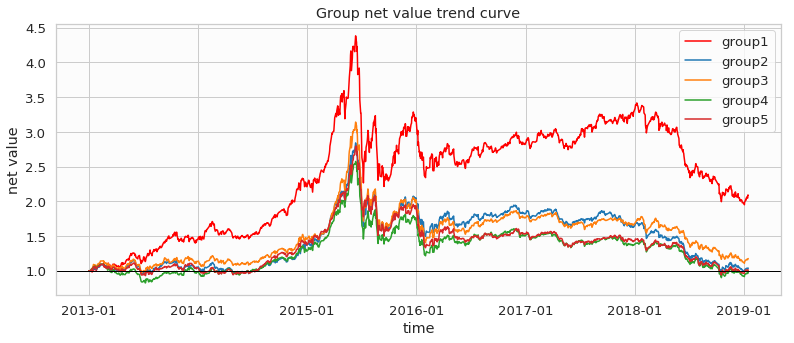

In [13]:
# 计算综合因子排名并执行分组回测
rank_combined = calculate_alpha_rank(M_gold, ym_end)

pf_comb1, nav_comb1 = get_group(1, 5, u1, u2, price_close, rank_combined, ym_end)
pf_comb2, nav_comb2 = get_group(2, 6, u1, u2, price_close, rank_combined, ym_end)
pf_comb3, nav_comb3 = get_group(3, 6, u1, u2, price_close, rank_combined, ym_end)
pf_comb4, nav_comb4 = get_group(4, 6, u1, u2, price_close, rank_combined, ym_end)
pf_comb5, nav_comb5 = get_group(5, 5, u1, u2, price_close, rank_combined, ym_end)

# 综合因子分组净值曲线可视化展示
plt.figure()
fig_comb = plt.figure(figsize=(13, 5))
ax_comb = fig_comb.add_subplot(1, 1, 1)

ax_comb.plot(nav_comb1, 'r', label='group1')
ax_comb.plot(nav_comb2, label='group2')
ax_comb.plot(nav_comb3, label='group3')
ax_comb.plot(nav_comb4, label='group4')
ax_comb.plot(nav_comb5, label='group5')

ax_comb.axhline(1.0, linestyle='-', color='black', lw=1)
ax_comb.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))

plt.legend(loc='best')
plt.xlabel('time')
plt.ylabel('net value')
plt.title('Group net value trend curve')
plt.show()

No handles with labels found to put in legend.


            0
分组一  0.127548
分组二  0.006031
分组三  0.026730
分组四 -0.004442
分组五  0.000000


<Figure size 432x288 with 0 Axes>

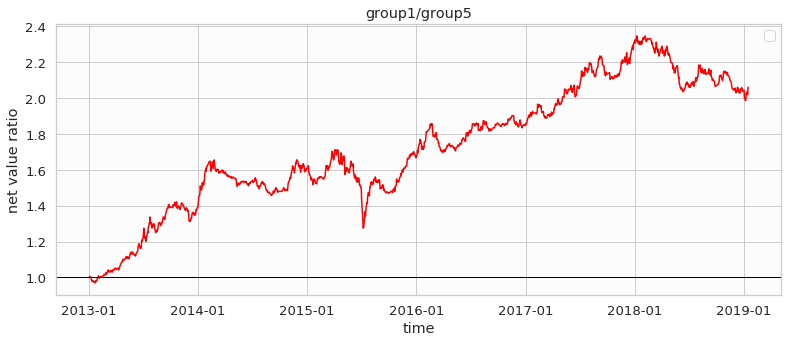

In [14]:
# 统计综合因子各分组的年化收益指标
annual_result = pd.DataFrame(np.zeros((5, 1)), index=['分组一', '分组二', '分组三', '分组四', '分组五'])
annual_result.iloc[0] = (a_gold1.iloc[-1]) ** (1 / (len(group01) / 240)) - 1
annual_result.iloc[1] = (a_gold2.iloc[-1]) ** (1 / (len(group01) / 240)) - 1
annual_result.iloc[2] = (a_gold3.iloc[-1]) ** (1 / (len(group01) / 240)) - 1
annual_result.iloc[3] = (a_gold4.iloc[-1]) ** (1 / (len(group01) / 240)) - 1

# 控制台打印年化收益率数据
print(annual_result)

# 构建头部组合与尾部组合的对冲收益率
diff_return = a_gold1.pct_change() - a_gold5.pct_change()
# 计算对冲组合的累计净值曲线
cumulative_value = (diff_return.fillna(0) + 1).cumprod()

# 生成对冲组合净值走势图
plt.figure()
demo_fig = plt.figure(figsize=(13, 5))
main_ax = demo_fig.add_subplot(1, 1, 1)

main_ax.plot(cumulative_value, 'r')
main_ax.axhline(1.0, linestyle='-', color='black', lw=1)
main_ax.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))

plt.legend(loc='best')
plt.xlabel('time')
plt.ylabel('net value ratio')
plt.title('group1/group5')
plt.show()

In [15]:
# 生成综合因子各组合的绩效评价表
perf_table_1 = pd.DataFrame(report(a_gold1.pct_change(), freqcy=1))
perf_table_1.index = ["组合一"]

perf_table_2 = pd.DataFrame(report(a_gold2.pct_change(), freqcy=1))
perf_table_2.index = ["组合二"]

perf_table_3 = pd.DataFrame(report(a_gold3.pct_change(), freqcy=1))
perf_table_3.index = ["组合三"]

perf_table_4 = pd.DataFrame(report(a_gold4.pct_change(), freqcy=1))
perf_table_4.index = ["组合四"]

perf_table_5 = pd.DataFrame(report(a_gold5.pct_change(), freqcy=1))
perf_table_5.index = ["组合五"]

# 合并所有组合绩效数据并展示
total_performance = pd.concat(
    [perf_table_1, perf_table_2, perf_table_3, perf_table_4, perf_table_5],
    axis=0
)
total_performance

,年化收益率,年化波动率,收益波动比,最大回撤
组合一,12.87%,26.64%,0.48,55.5%
组合二,0.61%,25.17%,0.02,65.38%
组合三,2.7%,25.33%,0.11,64.75%
组合四,-0.45%,24.63%,-0.02,65.02%
组合五,0.12%,24.15%,0.01,66.41%


# 5 结论
## 研究结论
本报告聚焦动量因子在行业轮动中的应用展开研究。基于“交易日内不同时段交易者行为模式存在差异”这一前提，我们对传统动量因子进行拆分处理，首次提出“日内动量+隔夜反转”的行业轮动黄金律。

通过对比传统动量因子与改进后动量因子的应用效果，可发现策略业绩存在显著提升：从头部组合表现来看，传统动量因子的年化收益率仅为20.37%，而改进后因子的年化收益率达到26.17%；在收益波动方面，改进后因子的最大回撤从70%降至64%左右。可见，无论是盈利能力还是盈利稳定性，改进后因子的表现均优于传统动量因子。

## 未来展望
本研究结果为后续相关研究提供了思路，即通过对传统因子进行改进，可有效提升其应用效果。此外，本报告中传统动量因子的参数默认设定为15天，该参数设置具有探讨空间，其取值可能对因子效果产生一定影响；同时，本报告未纳入换手因素，未考虑交易费用对策略收益的影响，上述问题均为后续值得深入研究的方向。